In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from scipy.stats import multivariate_normal, norm
from scipy.special import softmax, logsumexp

# Unsupervised learning

## Exercise 8.1: PCA on MNIST

In the lectures the principal component analysis (PCA) was introduced as a method for dimensionality reduction and feature extraction, i.e., to condense data by mapping it to a lower dimensional space of the most important features.

### Theoretical background

Let
\begin{equation*}
  \mathbf{X} = \begin{bmatrix} \mathbf{x}_1^\intercal \\ \vdots \\
    \mathbf{x}_N^\intercal \end{bmatrix} \in \mathbb{R}^{N \times D}
\end{equation*}
be a matrix of $N$ data samples $\mathbf{x}_n \in \mathbb{R}^D$, which are
centered around zero.
We consider a PCA with $M < D$ components.

To project the data points $\mathbf{x}_n$ to the $M$-dimensional space that is
defined by the $M$ principal components of $\mathbf{X}$, the so-called principal
subspace of $\mathbf{X}$, we can use the singular value decomposition of
$\mathbf{X}$. Let $\mathbf{X} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^\mathsf{T}$ be the
singular value decomposition of the data matrix $\mathbf{X}$ with the singular
values sorted in descending order.

Then the projection $\mathbf{z}_n$ of
data point $\mathbf{x}_n$ to the principal subspace of $\mathbf{X}$ is given by
\begin{equation}
  \mathbf{z}_n^\mathsf{T} = \mathbf{x}_n^\mathsf{T} \begin{bmatrix} \mathbf{v}_1 & \cdots & \mathbf{v}_M \end{bmatrix},
\end{equation}
where $\mathbf{v}_i$ is the $i$th column of matrix $\mathbf{V}$. The vector
$\mathbf{z}_n$ can be seen as an encoding of the data point
$\mathbf{x}_n$ in a lower dimensional space that is constructed by the directions
for which the data shows the largest variations.

With the help of the singular value decomposition of $\mathbf{X}$, we can also compute
reconstructions (or "decodings") $\tilde{\mathbf{x}}_n$ from the encodings $\mathbf{z}_n$ by
\begin{equation*}
  \tilde{\mathbf{x}}_n^\intercal = \mathbf{z}_n^\intercal \begin{bmatrix} \mathbf{v}^\intercal_1 \\ \vdots \\ \mathbf{v}^\intercal_M \end{bmatrix}.
\end{equation*}
If we use $M < D$ components, usually we are not able to recover the original data
from the lower dimensional encodings exactly. Ideally, we would like the
reconstructions to be as good as possible while keeping $M$ as small as possible.

##### Note

The singular value decomposition of a matrix $\mathbf{X} \in \mathbb{R}^{N \times D}$
is defined as a factorization of the form $\mathbf{X} = \mathbf{U} \mathbf{\Sigma}
\mathbf{V}^\mathsf{T}$ where $\mathbf{U} \in \mathbb{R}^{N \times N}$ and
$\mathbf{V} \in \mathbb{R}^{D \times D}$ are orthogonal matrices and
$\mathbf{\Sigma} \in \mathbb{R}^{N \times D}$ is a rectangular diagonal matrix with
non-negative numbers on the diagonal. The diagonal entries of $\mathbf{\Sigma}$ are
the so-called singular values of $\mathbf{X}$. A common convention is to sort
the singular values in descending order, in which case the diagonal matrix $\mathbf{\Sigma}$ is uniquely determined by $\mathbf{X}$.

### Introduction

In this exercise, we perform and analyse PCA of the MNIST image data set. The MNIST data set consists of 60000 training and 10000 test data points. Each data point consists of a grayscale image with 28 $\times$ 28 pixels of a handwritten digit. The digit has been size-normalized and centered within a fixed-sized image. Each image is also labeled with the digit (0, 1, ..., 8, or 9) it is depicting.

The following code block loads the MNIST data set.

In [6]:
# load MNIST data from https://www.openml.org/d/554
images, labels = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# normalize images to [0, 1]
images = images / 255

# convert labels to integers
labels = labels.astype(int)

# split into training and test dataset
train_images, train_labels = images[:60_000], labels[:60_000]
test_images, test_labels = images[60_000:], labels[60_000:]

The images are loaded as vectors $\mathbf{x} = [x_1 \dots x_{784}]^\mathsf{T}$ where each input variable $x_j$ corresponds to one of the $28 \times 28 = 784$ pixels in the image. The figure below shows the first 100 images in the training data set.

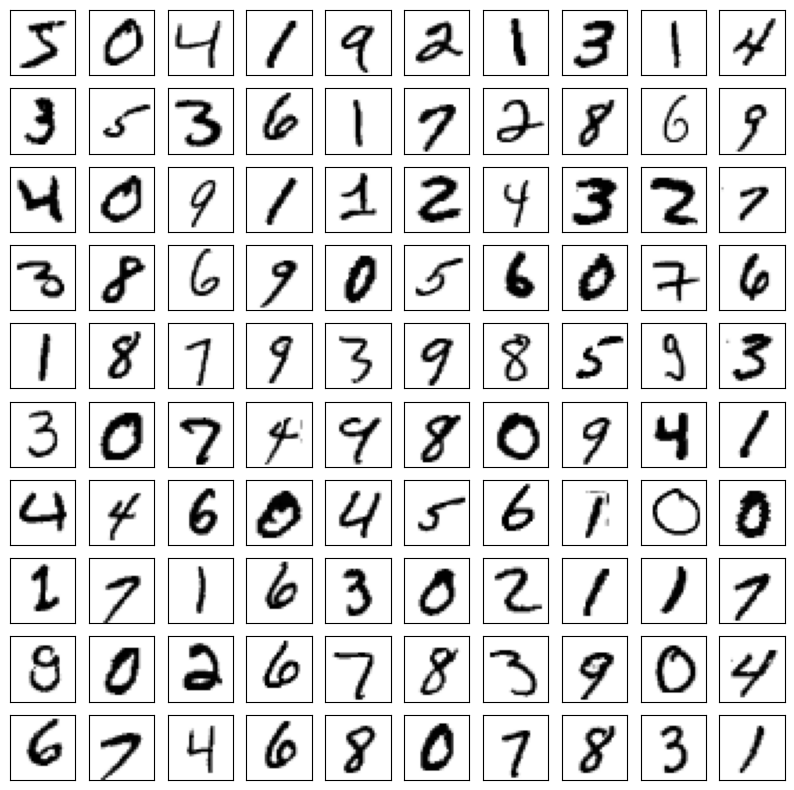

In [7]:
# plot first 100 training images
fig, axes = plt.subplots(nrows=10, ncols=10, figsize=(10, 10))
for image, ax in zip(train_images, axes.flat):
        ax.set_xticks(())
        ax.set_yticks(())
        ax.grid(False)
        ax.imshow(image.reshape(28, 28), vmin=0.0, vmax=1.0, cmap='gray_r')
plt.show()

Let
\begin{equation*}
  \mathbf{X} = \begin{bmatrix} \mathbf{x}_1^\mathsf{T} \\ \vdots \\
    \mathbf{x}_{60000}^\mathsf{T} \end{bmatrix} \in \mathbb{R}^{60000 \times 784}
\end{equation*}
be a matrix of the MNIST training data set where each row $\mathbf{x}_i^\mathsf{T}$ represents an image of the training data set (all pixels are normalized to the interval $[0, 1]$). This matrix is huge, it contains $60000 \times 784 = 47040000$ entries!

Many entries in this matrix are zeros (corresponding to white pixels), and in particular the entries corresponding to white pixels close to the margins of an image are probably not informative and not relevant. In this exercise we will study how much information is lost if we compress the MNIST data set to $M = 2$ principal components.

We define the mean of the training images as
\begin{equation*}
    \overline{\mathbf{x}} = \frac{1}{60000} \sum_{i=1}^{60000} \mathbf{x}_i,
\end{equation*}
and hence the centered training images are given by $\mathbf{X} - \overline{\mathbf{x}}^\mathsf{T}$.

We compute the singular value decomposition $\mathbf{X} - \overline{\mathbf{x}}^\mathsf{T} = \mathbf{U} \boldsymbol{\Sigma} \mathbf{V}^\mathsf{T}$ of the centered MNIST training data with the function [`numpy.linalg.svd`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html).

In [8]:
# center training images
train_mean = train_images.mean(axis=0)
train_images_centered = train_images - train_mean

U, S, Vt = np.linalg.svd(train_images_centered, full_matrices=False)

Variable `S` contains the singular values of `train_images_centered`, in descending order.

In [9]:
# four largest singular values
S[:4]

array([554.08236184, 473.79289646, 441.76832659, 412.90967564])

Note that `Vt` corresponds to $\mathbf{V}^\mathsf{T}$, i.e., it is the transpose of $\mathbf{V}$. We can recover `train_images_centered` from its singular value decomposition `U`, `S`, and `Vt`.

In [10]:
np.allclose(train_images_centered, U @ np.diag(S) @ Vt)

True

In [11]:
# alternative:
np.allclose(train_images_centered, (U * S) @ Vt)

True

### (a)

Compute the two-dimensional encodings of the images in the MNIST training and the test data set in the two-dimensional latent space spanned by the $M = 2$ principal components of the centered training data, the so-called principal subspace.

*Hints*:
- Make use of `U`, `S`, and/or `Vt`.
- Remember that the presence of the center $\overline{\textbf{x}}$ needs to be accounted for in the test data as well.

In [24]:
#print(S[:2])
#print(Vt[:2].shape)
#train_mean = train_images.mean(axis=0)
#train_images_centered = train_images - train_mean


#print(train_images_centered.shape)
zT_train = Vt[:2]@train_images_centered.T
print(zT_train.shape)

test_mean = test_images.mean(axis=0)
test_images_centered = test_images - test_mean

zT_test = Vt[:2]@test_images_centered.T
print(zT_test.shape)


[554.08236184 473.79289646]
(2, 784)
(60000, 784)
(2, 60000)
(2, 10000)


Generate 2D scatter plots of the encodings that show the clusters for different labels in the latent space. You can make use of the function `plot_encodings` below.

In [26]:
# plot `train_encodings` and `test_encodings` with colorcoding of the corresponding labels
def plot_encodings(train_encodings, train_labels, test_encodings, test_labels):
    # create two plots side by side
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

    # plot encodings of training data
    ax = axes[0]
    ax.scatter(
        train_encodings[:, 0], train_encodings[:, 1],
        c=train_labels, cmap=plt.cm.tab10, vmin=-0.5, vmax=9.5, alpha=0.7
    )
    ax.set_xlabel("$z_1$")
    ax.set_ylabel("$z_2$")
    ax.set_title("training data")

    # plot encodings of test data
    ax = axes[1]
    scatter = ax.scatter(
        test_encodings[:, 0], test_encodings[:, 1],
        c=test_labels, cmap=plt.cm.tab10, vmin=-0.5, vmax=9.5, alpha=0.7
    )
    ax.set_xlabel("$z_1$")
    ax.set_ylabel("$z_2$")
    ax.set_title("test data")

    # add colorbar
    cb = fig.colorbar(scatter, ticks=range(10), ax=axes.ravel().tolist())
    cb.ax.set_title("digit")

    return fig

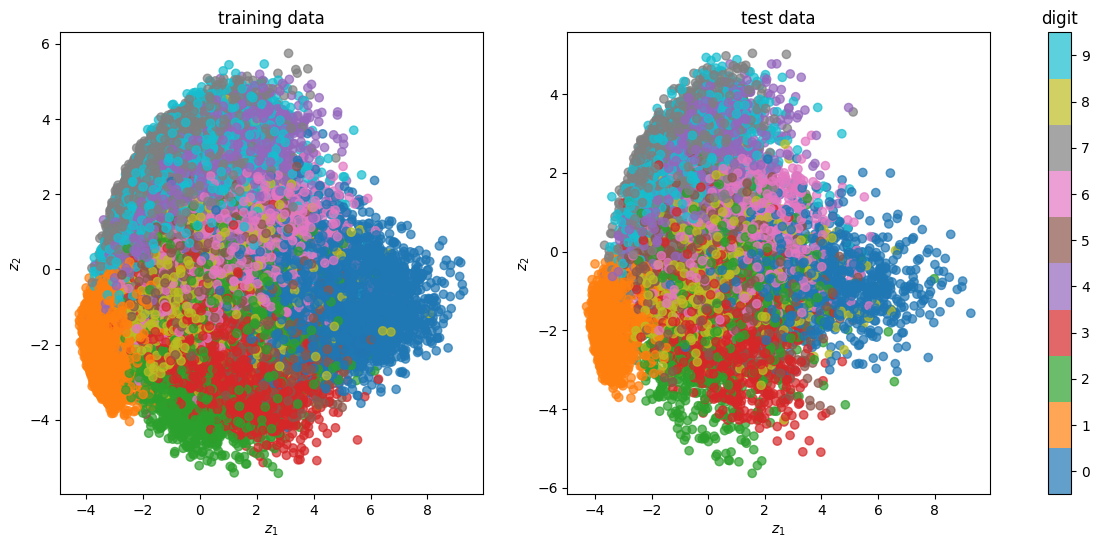

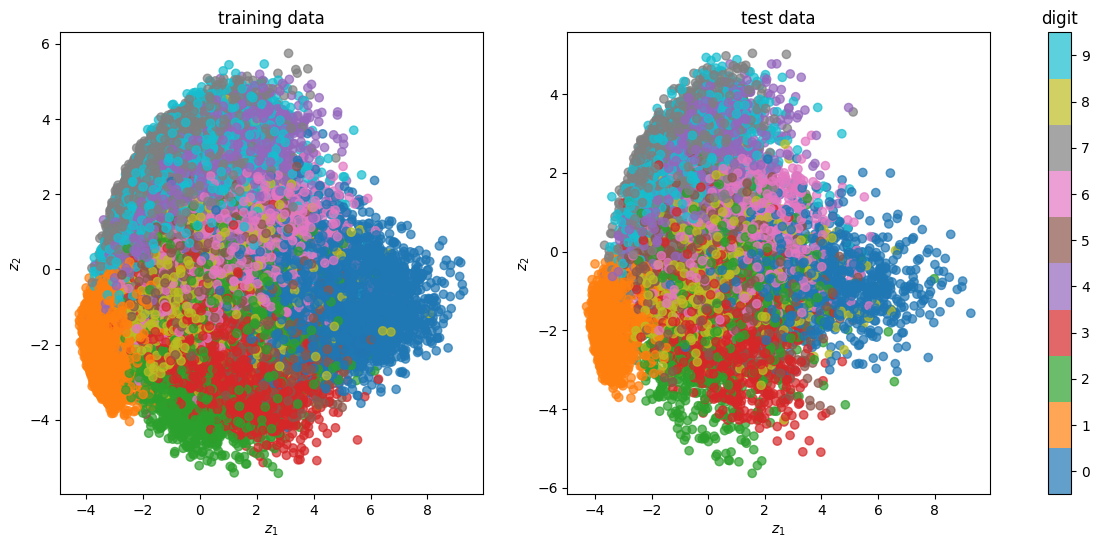

In [28]:
plot_encodings(zT_train.T, train_labels, zT_test.T, test_labels)

### (b)

Compute the reconstructions of the test images by mapping the encodings of the test data from the latent space back to the space of images.

In [46]:
#print(Vt[:2].shape)
#print(zT_train.T.shape)
x_train_recon = train_mean + zT_train.T@Vt[:2]
x_test_recon = test_mean + zT_test.T@Vt[:2]




Plot some test images and their reconstructed counterparts. You can use the function `plot_reconstructions` below. Which digits can be reconstructed and decoded quite well, and which ones seem to be more challenging? Remember that the reconstructions are obtained by considering only the two principal components.

In [47]:
# plot a grid of random pairs of `originals` and `reconstructions`
def plot_reconstructions(originals, reconstructions, labels, num_rows=4, num_cols=2):
    # indices of displayed samples
    n = originals.shape[0]
    indices = np.random.choice(n, size=num_rows*num_cols, replace=False)

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(10, 10))
    for (idx, ax) in zip(indices, axes.flat):
        # extract original, reconstruction, and label
        original = originals[idx]
        reconstruction = reconstructions[idx]
        label = labels[idx]

        # configure subplot
        ax.set_xticks(())
        ax.set_yticks(())
        ax.grid(False)
        ax.set_title(f"Label: {label}", fontweight='bold')

        # plot original and reconstructed image in a grid
        grid = np.ones((32, 62))
        grid[2:30, 2:30] = original.reshape(28, 28)
        grid[2:30, 32:60] = reconstruction.reshape(28, 28)
        ax.imshow(grid, vmin=0.0, vmax=1.0, cmap='gray_r')

    return fig

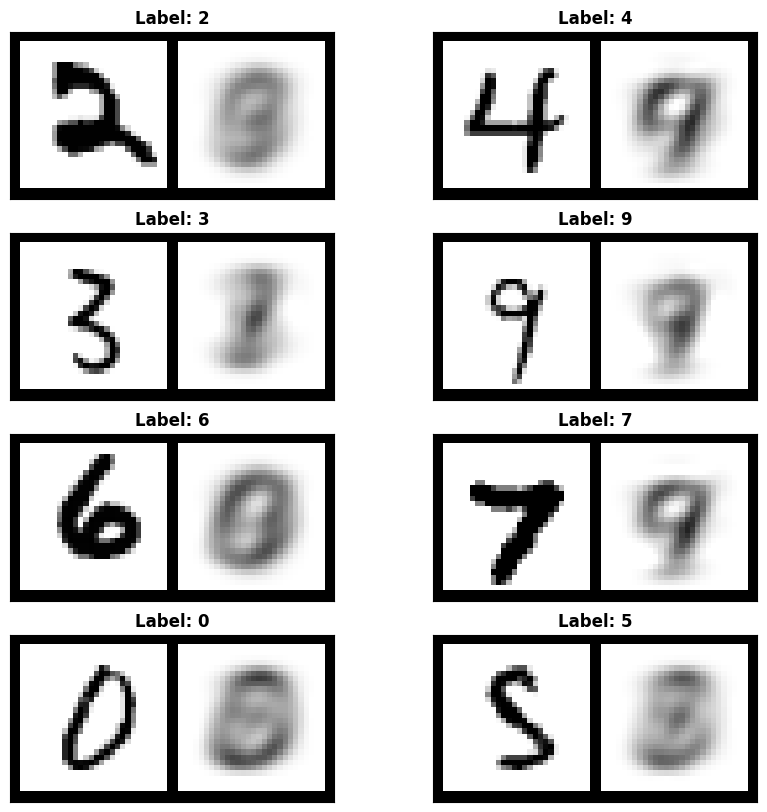

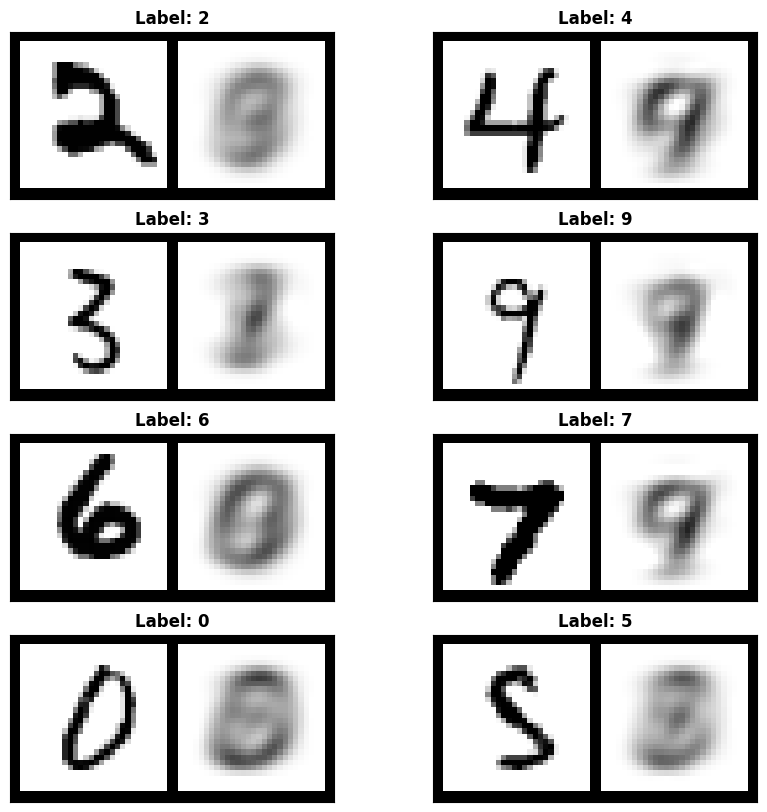

In [48]:
plot_reconstructions(test_images, x_test_recon, test_labels)

### (c)

The comparison of the original images and their reconstructions provides us with some intuition for how much information is lost by the compression of the images to the two-dimensional latent space. As a less subjective measure we calculate the average squared reconstruction error
\begin{equation*}
\mathrm{sqerr} := \frac{1}{10000} \sum_{i=1}^{10000} \|\mathbf{x}_i - \tilde{\mathbf{x}}_i\|^2_2
\end{equation*}
of the images $\mathbf{x}_i \in {[0,1]}^{784}$ and their reconstructions $\tilde{\mathbf{x}}_i \in \mathbb{R}^{784}$ ($i = 1,\ldots, 10000$) in the MNIST test data set. An advantage of an objective measure such as the average squared reconstruction error is that it enables us to compare the PCA with other models for dimensionality reduction.

What average squared reconstruction error do you get with PCA?

In [54]:
print(test_images.shape)
print(x_test_recon.shape)

sqerr = 1/len(test_images) * np.sum([(test_images[n,:]-x_test_recon[n,:])**2 for n in range(len(test_images))])
print(sqerr)

sqerr2 = ((test_images-x_test_recon)**2).sum(axis=1).mean()
print(sqerr2)

(10000, 784)
(10000, 784)
43.60299560115969
43.602995601159684


## Exercise 8.2 - Derivations for probabilistic PCA


In contrast to (regular) PCA, the so-called probabilistic PCA (PPCA) allows a probabilistic interpretation of the principal components. The probabilistic formulation of PCA also allows us to extend the method and alter its underlying assumptions quite easily.

As in exercise 8.1, let $\mathbf{x} \in \mathbb{R}^D$ represent a data sample that we
want to decode from a lower dimensional representation
$\mathbf{z} \in \mathbb{R}^M$ with $M < D$. The PPCA model assumes that
$\mathbf{z}$ is standard normally distributed and $\mathbf{x}$
can be decoded by a noisy linear transformation of $\mathbf{z}$.
Mathematically, the model is given by
\begin{align*}
  p(\mathbf{x} \,|\, \mathbf{z}) &= \mathcal{N}\left(\mathbf{x}; \mathbf{W}\mathbf{z} + \boldsymbol{\mu}, \sigma^2 \mathbf{I}_D\right), \\
  p(\mathbf{z}) &= \mathcal{N}(\mathbf{z}; \boldsymbol{0}, \mathbf{I}_M),
\end{align*}
with parameters $\mathbf{W} \in \mathbb{R}^{D \times M}$,
$\boldsymbol{\mu} \in \mathbb{R}^D$, and $\sigma^2 > 0$.
[Michael E. Tipping and Christopher M. Bishop show in "Probabilistic Principal Component Analysis"](https://www.jstor.org/stable/2680726)
that for $\sigma^2 \to 0$
the model recovers the standard PCA (but the components of $\mathbf{z}$ might
be permuted).

We assume that the data $\mathbf{x}_1, \ldots, \mathbf{x}_N$ is identically
and independently distributed according to the PPCA model. In a maximum
likelihood setting, one determines the parameters $\mathbf{W}$, $\boldsymbol{\mu}$,
and $\sigma^2$ that maximize the likelihood
\begin{equation*}
  p(\mathbf{x}_1, \ldots, \mathbf{x}_N ; \mathbf{W}, \boldsymbol{\mu}, \sigma^2)
  = \prod_{n=1}^N p(\mathbf{x}_n; \mathbf{W}, \boldsymbol{\mu}, \sigma^2),
\end{equation*}
or equivalently the log-likelihood
\begin{equation*}
  \log p(\mathbf{x}_1, \ldots, \mathbf{x}_N; \mathbf{W}, \boldsymbol{\mu}, \sigma^2)
  = \sum_{n=1}^N \log p(\mathbf{x}_n; \mathbf{W}, \boldsymbol{\mu}, \sigma^2).
\end{equation*}

### (a)

*(Pen and paper exercise)*

Show that for the model of the probabilistic PCA
\begin{equation*}
    p(\mathbf{x}) = \mathcal{N}(\mathbf{x}; \boldsymbol{\mu}, \mathbf{C}),
\end{equation*}
where $\mathbf{C} = \mathbf{W}\mathbf{W}^\mathsf{T} + \sigma^2 \mathbf{I}_D$.

### (b)

*(Pen and paper exercise)*

Show that the distribution of the latent variable $\mathbf{z}$ conditioned on $\mathbf{x}$ is Gaussian as well and given by
\begin{equation*}
    p(\mathbf{z} \,|\, \mathbf{x}) = \mathcal{N}\left(\mathbf{z}; \mathbf{M}^{-1} \mathbf{W}^\mathsf{T} (\mathbf{x} - \boldsymbol{\mu}), \sigma^2 \mathbf{M}^{-1} \right),
\end{equation*}
where $\mathbf{M} = \mathbf{W}^\mathsf{T} \mathbf{W} + \sigma^2 \mathbf{I}_M$.

## Exercise 8.3: Gaussian Mixture Model

In this exercise we estimate the parameters of a Gaussian mixture model with the expectation-maximization (EM) algorithm.

A Gaussian mixture model with $m \geq 1$ components consists of $m$ mixture components $\mathcal{N}(\mu_1, \Sigma_1), \ldots, \mathcal{N}(\mu_m, \Sigma_m)$ and corresponding non-negative mixture weights $w_1, \ldots, w_m$ with $\sum_{i=1}^m w_i = 1$. It has the probability density function
\begin{equation*}
    \operatorname{GMM}(x; w_1, \mu_1, \Sigma_1, \ldots, w_m, \mu_m, \Sigma_m) = \sum_{i=1}^m w_i \mathcal{N}(x; \mu_i, \Sigma_i).
\end{equation*}
One can obtain a sample $x$ from the Gaussian mixture model with a two-step procedure:
- Sample an index $d$ from the categorical distribution with probabilities $w_1, \ldots, w_m$.
- Sample $x$ from $\mathcal{N}(\mu_d, \Sigma_d)$.

We consider a data set $\mathbf{X} \in \mathbb{R}^{300 \times 2}$ of 300 samples that are generated from a two-dimensional Gaussian mixture model with mixture weights $w_1 = 0.7$ and $w_2 = 0.3$ and mixture components with parameters
\begin{equation*}
    \mu_1 = \begin{bmatrix} 5 \\ 7\end{bmatrix}, \quad \Sigma_1 = \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix}, \quad
    \mu_2 = \begin{bmatrix} 1 \\ 2\end{bmatrix}, \quad \Sigma_2 = \begin{bmatrix} 2 & 0 \\ 0 & 1 \end{bmatrix}.
\end{equation*}

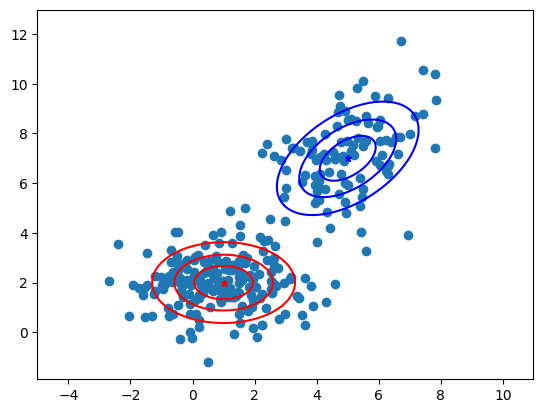

In [55]:
def plot_2dnormal(normal, color):
    # plot center
    plt.plot(normal.mean[0], normal.mean[1], '*', ms=5, color=color)

    # get countour grid
    x, y = np.mgrid[-3:3:.01, -3:3:.01]

    # rescale x, y
    x = normal.cov[0,0] * x + normal.mean[0]
    y = normal.cov[1,1] * y + normal.mean[1]

    # plot countour
    pos = np.dstack((x, y))
    plt.contour(x, y, normal.pdf(pos), colors=color, levels=3)

# mixture weights
weights = [0.7, 0.3]

# mixture components
component1 = multivariate_normal(mean=[1, 2], cov=[[2, 0], [0, 1]])
component2 = multivariate_normal(mean=[5, 7], cov=[[2, 1], [1, 2]])
components = [component1, component2]

# sample N = 300 samples from the Gaussian mixture model
np.random.seed(1234) # for reproducibility
N = 300
X = np.stack([np.random.choice(components, p=weights).rvs() for _ in range(N)])

plt.figure()
plt.scatter(X[:,0], X[:,1])
plot_2dnormal(component1, color='red')
plot_2dnormal(component2, color='blue')
plt.show()

### (a)

Implement a function `e_step(X, weights, components)` that receives as input
- data `X` (an array of size $300 \times 2$ in the model above),
- mixture `weights` (a list `[p, 1 - p]` in the model above), and
- mixture `components` (a list of two [`multivariate_normal`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html) distributions in the model above).

and outputs a matrix of the likelihood of each data point for each mixture component. More concretely, the entry at the $i$th row and $j$th column of the returned matrix should be
\begin{equation*}
    \frac{w_i \mathcal{N}\left(x_j; \mu_i, \Sigma_i\right)}{\sum_{k=1}^m w_k \mathcal{N}\left(x_j; \mu_k , \Sigma_k\right)}.
\end{equation*}
I.e., in the example here the function should return a matrix of size $2 \times 300$.

This computation corresponds to the expectation step in the EM algorithm.

Based on the output of `e_step` we can estimate to which mixture component a data point seems to belong.

In [ ]:
# evaluate the function on the dataset
probs = e_step(X, weights, components)

# compute to which component data points seem to belong
belong_to = probs.argmax(axis=0)

# plot data
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=belong_to)
for c in components:
    plot_2dnormal(c, color='black')
plt.show()

### (b)

Implement the M-step of the EM algorithm with a function `m_step(X, probs)` that receives as input
- the data `X` (an array of size $300 \times 2$ in the model above) and
- the probabilities `probs` (output of `e_step` implemented above, array of size $2 \times 300$ in the model above)

and outputs the updated parameter estimates of the Gaussian mixture model, i.e.,
- the weights of the mixture components (a list `[p, 1 - p]` in the model above) and
- the mixture components (a list of two [`multivariate_normal`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html) distributions in the model above).

*Hint:* The formulas for the updated parameter estimates can be found in eq. 10.16 in http://smlbook.org/.

We can perform a sanity check:

In [ ]:
weights, components = m_step(X, probs)

print('weights:')
print(weights)
for i, c in enumerate(components):
    print('')
    print('Normal {}'.format(i+1))
    print('- mean:')
    print(c.mean)
    print('- cov:')
    print(c.cov)

If everything went right, you should obtain estimates close to the ones used to generate the dataset:
- Mixture weights should be close to $[0.7, 0.3]$
- The first Gaussian mixture component should be close to
  \begin{equation*}
    \mathcal{N}\left(\begin{bmatrix} 1 \\ 2\end{bmatrix}, \begin{bmatrix} 2 & 0 \\ 0 & 1 \end{bmatrix}\right)
  \end{equation*}
- The second Gaussian mixture component should be close to
  \begin{equation*}
    \mathcal{N}\left(\begin{bmatrix} 5 \\ 7\end{bmatrix}, \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix}\right)
  \end{equation*}

### (c)

Run the code below to plot 3 iterations of the EM algorithm.

In [ ]:
# initial parameter estimates
component1_estimated = multivariate_normal(mean=[0, 0], cov=np.eye(2))
component2_estimated  = multivariate_normal(mean=[10, 10], cov=np.eye(2))
components_estimated = [component1_estimated, component2_estimated]
weights_estimated = [0.5, 0.5]

for i in range(3):
    # expectation step
    probs = e_step(X, weights_estimated, components_estimated)
    belong_to = probs.argmax(axis=0)

    # plot estimates
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], c=belong_to)
    for c in components_estimated:
        plot_2dnormal(c, color='black')
    plt.title(f"iteration {i}")
    plt.show()

    # maximization step
    weights_estimated, components_estimated = m_step(X, probs)

### (d)

Adapt the code in exercise 8.3 c) and use the EM algorithm to estimate the parameters of a Gaussian mixture model for the two-dimensional encodings of the MNIST training data set computed in exercise 8.1. You have to choose the number of mixture components and the initial parameter estimates.

## Exercise 8.4: Challenge Problem: Mixture of linear regressions

The EM algorithm is not restricted to clustering. In this exercise we use it for a problem that combines the Gaussian mixture model from exercise 8.3 with the linear regression models from the earlier sessions: the data consists of pairs $(x_n, y_n)$ that are generated by *several* linear relationships, but for each data point we do not know which relationship generated it.

We consider a mixture of $K$ linear regression models
\begin{align*}
  p(c_n = k) &= \pi_k, \\
  p(y_n \,|\, x_n, c_n = k) &= \mathcal{N}\left(y_n; \mathbf{w}_k^\mathsf{T} \boldsymbol{\phi}(x_n), \beta_k^{-1}\right),
\end{align*}
where $c_n \in \{1, \ldots, K\}$ is a latent variable that indicates which component generated data point $n$ and $\boldsymbol{\phi}(x) = [1 \;\, x]^\mathsf{T}$ is the feature vector. The parameters of the model are the mixture weights $\pi_1, \ldots, \pi_K \geq 0$ with $\sum_{k=1}^K \pi_k = 1$, the regression weights $\mathbf{w}_1, \ldots, \mathbf{w}_K \in \mathbb{R}^2$, and the noise precisions $\beta_1, \ldots, \beta_K > 0$. Marginalizing out $c_n$ yields
\begin{equation*}
  p(y_n \,|\, x_n) = \sum_{k=1}^K \pi_k \mathcal{N}\left(y_n; \mathbf{w}_k^\mathsf{T} \boldsymbol{\phi}(x_n), \beta_k^{-1}\right).
\end{equation*}
Note that we denote the mixture weights by $\pi_k$ (instead of $w_k$ as in exercise 8.3) to avoid confusion with the regression weights $\mathbf{w}_k$.

As in the earlier sessions, we collect the feature vectors of $N$ data points in the matrix $\boldsymbol{\Phi} \in \mathbb{R}^{N \times 2}$ with rows $\boldsymbol{\phi}(x_n)^\mathsf{T}$, and the targets in the vector $\mathbf{y} = [y_1 \cdots y_N]^\mathsf{T}$.

The following code generates $N = 200$ data points from a mixture of two lines with mixture weights $\pi_1 = 0.6$ and $\pi_2 = 0.4$, regression weights $\mathbf{w}_1 = [1 \;\, 1.5]^\mathsf{T}$ and $\mathbf{w}_2 = [3 \;\, {-1}]^\mathsf{T}$, and noise standard deviations $\beta_1^{-1/2} = 0.5$ and $\beta_2^{-1/2} = 0.8$.

In [ ]:
# true parameters (row k of `true_W` contains intercept and slope of line k)
true_pis = np.array([0.6, 0.4])
true_W = np.array([[1.0, 1.5], [3.0, -1.0]])
true_betas = np.array([1 / 0.5**2, 1 / 0.8**2])

# sample N = 200 data points from the mixture of linear regressions
np.random.seed(1234) # for reproducibility
N = 200
x = np.random.uniform(-3, 3, size=N)
c = np.random.choice(2, size=N, p=true_pis)
Phi = np.column_stack([np.ones(N), x]) # feature matrix with rows [1, x_n]
y = np.sum(Phi * true_W[c], axis=1) + np.random.normal(size=N) / np.sqrt(true_betas[c])

plt.figure()
plt.scatter(x, y)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

### (a)

*(Pen and paper exercise)*

Derive the EM algorithm for the mixture of linear regressions.

- **E-step:** Show that the posterior probability that data point $n$ was generated by component $k$ (the so-called responsibility) is
\begin{equation*}
    r_{nk} := p(c_n = k \,|\, x_n, y_n) = \frac{\pi_k \mathcal{N}\left(y_n; \mathbf{w}_k^\mathsf{T} \boldsymbol{\phi}(x_n), \beta_k^{-1}\right)}{\sum_{j=1}^K \pi_j \mathcal{N}\left(y_n; \mathbf{w}_j^\mathsf{T} \boldsymbol{\phi}(x_n), \beta_j^{-1}\right)}.
\end{equation*}
- **M-step:** Maximize
\begin{equation*}
    Q = \sum_{n=1}^N \sum_{k=1}^K r_{nk} \log\left(\pi_k \mathcal{N}\left(y_n; \mathbf{w}_k^\mathsf{T} \boldsymbol{\phi}(x_n), \beta_k^{-1}\right)\right)
\end{equation*}
with respect to $\mathbf{w}_k$, $\beta_k$, and $\pi_k$. Show that the update of $\mathbf{w}_k$ is the solution of a *weighted* least squares problem, and derive a closed-form expression for it. How is it related to the maximum likelihood estimate of a single linear regression model ($K = 1$)?

*Hints*:
- It is convenient to introduce the diagonal matrix $\mathbf{R}_k = \operatorname{diag}(r_{1k}, \ldots, r_{Nk})$ and $N_k = \sum_{n=1}^N r_{nk}$.
- The update of the mixture weights is the same as for the Gaussian mixture model (eq. 10.16a in http://smlbook.org/).

### (b)

Implement the EM algorithm from (a):
- a function `e_step_regression(Phi, y, pis, W, betas)` that returns the $K \times N$ matrix of responsibilities $r_{nk}$ (the entry in the $k$th row and $n$th column should be $r_{nk}$, analogously to `e_step` in exercise 8.3),
- a function `m_step_regression(Phi, y, probs)` that receives the responsibilities and returns the updated parameters `pis` (array of size $K$), `W` (array of size $K \times 2$ whose $k$th row is $\mathbf{w}_k^\mathsf{T}$), and `betas` (array of size $K$), and
- a function `log_likelihood_regression(Phi, y, pis, W, betas)` that returns the log-likelihood $\sum_{n=1}^N \log p(y_n \,|\, x_n)$.

*Hint*: As in exercise 8.3 it is numerically better to work with log-probabilities, e.g., with [`norm.logpdf`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html), [`softmax`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.softmax.html), and [`logsumexp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.logsumexp.html).

In [ ]:
def e_step_regression(Phi, y, pis, W, betas):
    # K x N matrix of responsibilities r_nk
    probs = ...
    return probs

def log_likelihood_regression(Phi, y, pis, W, betas):
    # log-likelihood sum_n log p(y_n | x_n)
    log_likelihood = ...
    return log_likelihood

def m_step_regression(Phi, y, probs):
    # mixture weights, array of size K
    pis = ...
    # regression weights (weighted least squares), array of size K x 2 whose kth row is w_k^T
    W = ...
    # noise precisions, array of size K
    betas = ...
    return pis, W, betas


We use the following functions to plot the data together with the estimated lines, and to run the EM algorithm for a given number of iterations while tracking the log-likelihood. Similar to exercise 8.3, the data points are colored according to the component that they most likely belong to.

In [ ]:
# plot data points colored by most likely component and the lines of all components
def plot_regression_mixture(x, y, W, probs, ax):
    belong_to = probs.argmax(axis=0)
    ax.scatter(x, y, c=belong_to, cmap=plt.cm.tab10, vmin=-0.5, vmax=9.5, alpha=0.5)
    xs = np.linspace(x.min(), x.max(), 2)
    for k, w in enumerate(W):
        ax.plot(xs, w[0] + w[1] * xs, color=plt.cm.tab10(k), linewidth=3)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

# run `num_iterations` iterations of the EM algorithm with the given M-step
def run_em_regression(Phi, y, pis, W, betas, num_iterations, m_step=None):
    if m_step is None:
        m_step = m_step_regression
    log_likelihoods = [log_likelihood_regression(Phi, y, pis, W, betas)]
    for _ in range(num_iterations):
        probs = e_step_regression(Phi, y, pis, W, betas)
        pis, W, betas = m_step(Phi, y, probs)
        log_likelihoods.append(log_likelihood_regression(Phi, y, pis, W, betas))
    return pis, W, betas, np.array(log_likelihoods)

Run the code below to plot the first iterations of the EM algorithm.

In [ ]:
# initial parameter estimates
pis_init = np.array([0.5, 0.5])
W_init = np.array([[0.0, 1.0], [0.0, -1.0]])
betas_init = np.array([1.0, 1.0])

pis_estimated, W_estimated, betas_estimated = pis_init, W_init, betas_init
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    # expectation step
    probs = e_step_regression(Phi, y, pis_estimated, W_estimated, betas_estimated)

    # plot estimates
    plot_regression_mixture(x, y, W_estimated, probs, ax)
    ax.set_title(f"iteration {i}")

    # maximization step
    pis_estimated, W_estimated, betas_estimated = m_step_regression(Phi, y, probs)
plt.show()

Run the EM algorithm for 100 iterations with the same initial parameter estimates and plot the log-likelihood as a function of the iterations. Does the log-likelihood ever decrease? Compare the final parameter estimates with the parameters that were used to generate the data.

### (c)

*(Pen and paper exercise)*

Suppose that all $K$ components are initialized with the same regression weights and noise precisions, i.e., $\mathbf{w}_k = \mathbf{w}$ and $\beta_k = \beta$ for all $k$ (the mixture weights $\pi_k$ may be arbitrary). Show that the EM algorithm never leaves such a configuration. What are the parameter estimates after one iteration, and which well-known estimator do you obtain?

Verify your answer numerically by running the EM algorithm with `W_init = np.zeros((2, 2))`. How can this problem be avoided in practice?

### (d)

We now fit a mixture of $K = 3$ linear regressions to the same data. We initialize the first two components as in (b), and the third component with a line that passes exactly through the first two data points and a large noise precision $\beta_3 = 10^4$.

In [ ]:
# line through the first two data points
slope = (y[1] - y[0]) / (x[1] - x[0])
w3 = np.array([y[0] - slope * x[0], slope])

# initial parameter estimates
pis_init3 = np.ones(3) / 3
W_init3 = np.vstack([W_init, w3])
betas_init3 = np.array([1.0, 1.0, 1e4])

Run the EM algorithm for (up to) 20 iterations with this initialization and plot the log-likelihood. What happens to the estimate of $\beta_3$? Compare the final log-likelihood with the one obtained in (b). Is the solution with larger log-likelihood the better model of the data?

*(Pen and paper exercise)* Show that the likelihood $\prod_{n=1}^N p(y_n \,|\, x_n)$ of the mixture of linear regressions with $K \geq 2$ components is unbounded. What does this imply for maximum likelihood estimation in this model?

### (e)

The singularity in (d) can be avoided by putting a prior on the parameters and computing a maximum a posteriori (MAP) estimate instead. We use the Gauss-Gamma prior from the exercises on Bayesian linear regression (with prior mean $\boldsymbol{0}$ and prior covariance matrix $\lambda^{-1} \mathbf{I}_2$) independently for each component,
\begin{equation*}
    p(\mathbf{w}_k, \beta_k) = \mathcal{N}\left(\mathbf{w}_k; \boldsymbol{0}, {(\lambda \beta_k)}^{-1} \mathbf{I}_2\right) \operatorname{Gam}(\beta_k; a_0, b_0),
\end{equation*}
with hyperparameters $\lambda > 0$, $a_0 \geq 1$, and $b_0 > 0$, where $\operatorname{Gam}(\beta; a, b) = \frac{1}{\Gamma(a)} b^a \beta^{a - 1} e^{-b\beta}$. The EM algorithm can be used to compute the MAP estimate: the E-step does not change, and in the M-step we maximize $Q + \sum_{k=1}^K \log p(\mathbf{w}_k, \beta_k)$ instead of $Q$.

*(Pen and paper exercise)* Derive the updates of $\mathbf{w}_k$ and $\beta_k$ in the M-step (the update of the mixture weights $\pi_k$ does not change). Which regularized version of least squares do you obtain for $\mathbf{w}_k$? Explain why the collapse from (d) can not occur anymore.

Implement a function `m_step_regression_map(Phi, y, probs)` with the MAP updates, using $\lambda = 1$, $a_0 = 2$, and $b_0 = 0.5$, and run the EM algorithm with the initialization from (d) for 100 iterations. What happens to the third component?

In [ ]:
def m_step_regression_map(Phi, y, probs, lam=1.0, a0=2.0, b0=0.5):
    D = Phi.shape[1]

    # mixture weights (unchanged), array of size K
    pis = ...
    # regression weights, array of size K x 2 whose kth row is w_k^T
    W = ...
    # noise precisions, array of size K
    betas = ...
    return pis, W, betas


### (f)

Finally, we use the mixture of linear regressions for a quite different purpose: *robust regression*. The following data set is generated from a single line $y = 2 + 0.5 x$ with small noise, but it is contaminated with 15 outliers.

In [ ]:
np.random.seed(1) # for reproducibility
N_inliers, N_outliers = 40, 15

# inliers
x_robust = np.random.uniform(0, 10, size=N_inliers + N_outliers)
y_robust = 2 + 0.5 * x_robust + np.random.normal(scale=0.4, size=N_inliers + N_outliers)

# outliers
x_robust[N_inliers:] = np.random.uniform(5, 10, size=N_outliers)
y_robust[N_inliers:] = np.random.uniform(-6, 2, size=N_outliers)

Phi_robust = np.column_stack([np.ones_like(x_robust), x_robust])

plt.figure()
plt.scatter(x_robust, y_robust)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.show()

Compute the least squares estimate of the regression weights of a single line and plot it together with the data. Then fit a mixture of $K = 2$ linear regressions with your implementation from (b), where you initialize both components with the least squares estimate, the mixture weights with $[0.5, 0.5]$, and the noise precisions with $[1, 0.01]$. Why does this initialization not suffer from the problem in (c)?

Plot the line of the component with the largest noise precision together with the least squares line. Visualize for each data point the probability that it is an outlier, i.e., that it was not generated by this component.

*Hint*: This idea is discussed in detail in the (quite entertaining) article [Data analysis recipes: Fitting a model to data](https://arxiv.org/abs/1008.4686) by Hogg, Bovy, and Lang.